# 🏥 Predicting Medical Insurance Claim Amounts

## Objective
Estimate the medical insurance claim amount based on personal data using regression modeling.

**Dataset:** [Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

**Instructions:**
- Train a Linear Regression model to predict charges.
- Visualize how BMI, age, and smoking status impact insurance charges.
- Evaluate model performance using MAE and RMSE.

---

**Skills:**  
- Regression modeling  
- Feature correlation and visualization  
- Error evaluation (MAE, RMSE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [2]:
df = pd.read_csv("/kaggle/input/datasets/kinzaemannn/medical-insurance/insurance.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)

Dataset Shape: 1338 rows × 7 columns



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 📋 Dataset Description

| Feature    | Description                                 |
|------------|---------------------------------------------|
| age        | Age of primary beneficiary                  |
| sex        | Insurance policy holder’s gender            |
| bmi        | Body Mass Index                             |
| children   | Number of children covered by insurance     |
| smoker     | Smoking status (yes/no)                     |
| region     | Residential area in the US                  |
| charges    | **Target** — Medical insurance claim amount |

In [3]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY — Numerical Features")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df.columns:
    print(f"{col:15s} → {df[col].nunique():6d} unique  |  dtype: {df[col].dtype}")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

STATISTICAL SUMMARY — Numerical Features


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



UNIQUE VALUES PER COLUMN
age             →     47 unique  |  dtype: int64
sex             →      2 unique  |  dtype: object
bmi             →    548 unique  |  dtype: float64
children        →      6 unique  |  dtype: int64
smoker          →      2 unique  |  dtype: object
region          →      4 unique  |  dtype: object
charges         →   1337 unique  |  dtype: float64


✅ No missing values found in the dataset!


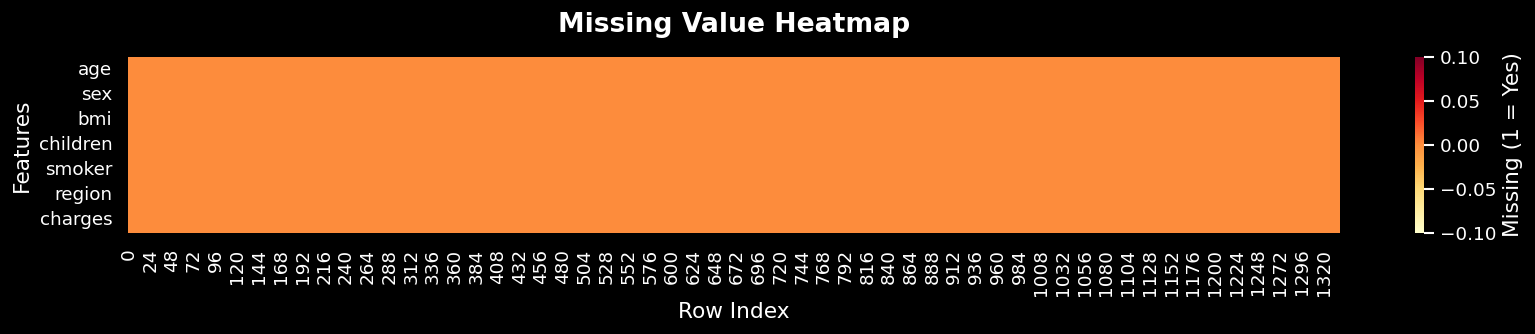

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Percentage (%)", ascending=False)

if missing_df.empty:
    print("✅ No missing values found in the dataset!")
else:
    print("Missing Values Summary:\n")
    print(missing_df)

# Visualize missing values (should be empty for this dataset)
import matplotlib.pyplot as plt
import seaborn as sns

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(14, 3))
    sns.heatmap(df.isnull().T, cbar=True, cmap="YlOrRd", yticklabels=True, ax=ax,
                cbar_kws={"label": "Missing (1 = Yes)"})
    ax.set_title("Missing Value Heatmap", fontweight="bold", pad=15)
    ax.set_xlabel("Row Index")
    ax.set_ylabel("Features")
    plt.tight_layout()
    plt.show()

In [5]:
# Encode categorical variables: sex and smoker (binary), region (one-hot)
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

print("✅ Categorical variables encoded.")
print(f"Columns after encoding: {list(df.columns)}")
df.head()

✅ Categorical variables encoded.
Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [6]:
print("DataFrame shape:", df.shape)
print(df.head())
print(df.info())

DataFrame shape: (1338, 9)
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   b

In [7]:
# ============================================================
# STEP 7: Interactive Visualizations — BMI, Age, Smoking vs Charges
# ============================================================

import plotly.io as pio
pio.renderers.default = "iframe"

import plotly.subplots as sp
import plotly.graph_objects as go

# Map smoker for clarity
df["smoker_label"] = df["smoker"].map({0: "Non-Smoker", 1: "Smoker"})

# Create a subplot grid: 1 row, 3 columns
fig = sp.make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "BMI vs Charges (Colored by Smoking Status)",
        "Age vs Charges (Colored by Smoking Status)",
        "Charges by Smoking Status (Boxplot)"
    ],
    horizontal_spacing=0.08
)

# --- 1. BMI vs Charges (Scatter) ---
for label, color in zip(["Non-Smoker", "Smoker"], ["#3498db", "#e74c3c"]):
    subset = df[df["smoker_label"] == label]
    fig.add_trace(
        go.Scatter(
            x=subset["bmi"], y=subset["charges"],
            mode="markers",
            name=f"BMI - {label}",
            marker=dict(size=8, color=color, opacity=0.65, line=dict(width=1, color="white")),
            hovertemplate="BMI: %{x}<br>Charges: $%{y:,.0f}<br>Age: %{customdata[0]}<br>Sex: %{customdata[1]}",
            customdata=np.stack((subset["age"], subset["sex"]), axis=-1),
            legendgroup=label,
            showlegend=True if label == "Non-Smoker" else False  # Only show legend once
        ),
        row=1, col=1
    )

# --- 2. Age vs Charges (Scatter) ---
for label, color in zip(["Non-Smoker", "Smoker"], ["#3498db", "#e74c3c"]):
    subset = df[df["smoker_label"] == label]
    fig.add_trace(
        go.Scatter(
            x=subset["age"], y=subset["charges"],
            mode="markers",
            name=f"Age - {label}",
            marker=dict(size=8, color=color, opacity=0.65, line=dict(width=1, color="white")),
            hovertemplate="Age: %{x}<br>Charges: $%{y:,.0f}<br>BMI: %{customdata[0]}<br>Sex: %{customdata[1]}",
            customdata=np.stack((subset["bmi"], subset["sex"]), axis=-1),
            legendgroup=label,
            showlegend=True
        ),
        row=1, col=2
    )

# --- 3. Charges by Smoking Status (Boxplot) ---
for label, color in zip(["Non-Smoker", "Smoker"], ["#3498db", "#e74c3c"]):
    subset = df[df["smoker_label"] == label]
    fig.add_trace(
        go.Box(
            y=subset["charges"],
            name=label,
            marker_color=color,
            boxmean="sd",
            boxpoints="all",
            jitter=0.4,
            pointpos=0,
            line=dict(width=2),
            fillcolor=color,
            opacity=0.6,
            showlegend=False
        ),
        row=1, col=3
    )

# --- Layout and Style ---
fig.update_layout(
    title="Interactive Analysis: BMI, Age, and Smoking Status vs Insurance Charges",
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=15, color="white"),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    width=1700,
    height=600,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.08,
        xanchor="center",
        x=0.5,
        font=dict(size=15, color="white"),
        bgcolor="rgba(0,0,0,0)"
    ),
    margin=dict(l=40, r=40, t=90, b=40)
)

fig.update_xaxes(title_text="BMI", row=1, col=1, color="#FFD700", gridcolor="#444")
fig.update_yaxes(title_text="Charges ($)", row=1, col=1, color="#FFD700", gridcolor="#444")

fig.update_xaxes(title_text="Age", row=1, col=2, color="#FFD700", gridcolor="#444")
fig.update_yaxes(title_text="Charges ($)", row=1, col=2, color="#FFD700", gridcolor="#444")

fig.update_xaxes(title_text="Smoking Status", row=1, col=3, color="#FFD700", gridcolor="#444")
fig.update_yaxes(title_text="Charges ($)", row=1, col=3, color="#FFD700", gridcolor="#444")

fig.show()

# Clean up helper column
df.drop("smoker_label", axis=1, inplace=True)

In [8]:
import plotly.io as pio
pio.renderers.default = "iframe"

import plotly.express as px

# Add a readable label for smoker
df["smoker_label"] = df["smoker"].map({0: "Non-Smoker", 1: "Smoker"})

# 1. BMI vs Charges (scatter, colored by smoker)
fig_bmi = px.scatter(
    df, x="bmi", y="charges", color="smoker_label",
    title="BMI vs Insurance Charges (Colored by Smoking Status)",
    labels={"bmi": "BMI", "charges": "Insurance Charges", "smoker_label": "Smoking Status"},
    hover_data=["age", "sex"],
    width=1100, height=550,
    color_discrete_map={"Non-Smoker": "#3498db", "Smoker": "#e74c3c"}
)
fig_bmi.update_traces(marker=dict(size=9, opacity=0.7, line=dict(width=1, color='white')))
fig_bmi.update_layout(
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    legend=dict(title="Smoking Status", font=dict(size=15, color="white")),
    margin=dict(l=60, r=60, t=80, b=60)
)
fig_bmi.show()

# 2. Age vs Charges (scatter, colored by smoker)
fig_age = px.scatter(
    df, x="age", y="charges", color="smoker_label",
    title="Age vs Insurance Charges (Colored by Smoking Status)",
    labels={"age": "Age", "charges": "Insurance Charges", "smoker_label": "Smoking Status"},
    hover_data=["bmi", "sex"],
    width=1100, height=550,
    color_discrete_map={"Non-Smoker": "#3498db", "Smoker": "#e74c3c"}
)
fig_age.update_traces(marker=dict(size=9, opacity=0.7, line=dict(width=1, color='white')))
fig_age.update_layout(
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    legend=dict(title="Smoking Status", font=dict(size=15, color="white")),
    margin=dict(l=60, r=60, t=80, b=60)
)
fig_age.show()

# 3. Charges by Smoking Status (boxplot)
fig_box = px.box(
    df, x="smoker_label", y="charges", color="smoker_label",
    title="Insurance Charges by Smoking Status",
    labels={"smoker_label": "Smoking Status", "charges": "Insurance Charges"},
    points="all", notched=True,
    width=900, height=550,
    color_discrete_map={"Non-Smoker": "#3498db", "Smoker": "#e74c3c"}
)
fig_box.update_traces(marker=dict(opacity=0.5))
fig_box.update_layout(
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    showlegend=False,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig_box.show()

# Clean up helper column
df.drop("smoker_label", axis=1, inplace=True)

In [9]:
# ============================================================
# STEP 8: Interactive Correlation Heatmap (Plotly)
# ============================================================

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"

corr_matrix = df.corr(numeric_only=True).round(2)

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu",
    title="Interactive Correlation Heatmap — All Features",
    aspect="auto",
    width=950,
    height=800
)

fig.update_layout(
    font=dict(size=16, color="white"),
    title_font=dict(size=24, color="#00E5FF"),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    margin=dict(l=80, r=80, t=80, b=80)
)
fig.update_xaxes(side="top", tickfont=dict(color="white"))
fig.update_yaxes(tickfont=dict(color="white"))

fig.show()

In [10]:
# ============================================================
# STEP 9: Train-Test Split & Feature Scaling
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop("charges", axis=1)
y = df["charges"]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 1070 samples
Testing set:  268 samples


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # or whatever model you're using
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Generate predictions
y_pred = model.predict(X_test)

# 4. Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")

Mean Absolute Error (MAE):  $4,181.19
Root Mean Squared Error (RMSE):  $5,796.28


In [14]:
# ============================================================
# STEP 11: Interactive Actual vs Predicted Charges Plot
# ============================================================

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "iframe"

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    marker=dict(size=8, color="#00E5FF", opacity=0.7, line=dict(width=1, color='white')),
    name="Predicted vs Actual",
    hovertemplate="Actual: $%{x:,.0f}<br>Predicted: $%{y:,.0f}"
))

# Add perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    line=dict(color="#FFD700", width=3, dash="dash"),
    name="Perfect Prediction"
))

fig.update_layout(
    title="Interactive Plot: Actual vs Predicted Insurance Charges",
    xaxis_title="Actual Charges ($)",
    yaxis_title="Predicted Charges ($)",
    font=dict(size=16, color="white"),
    title_font=dict(size=24, color="#00E5FF"),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    width=900,
    height=700,
    legend=dict(font=dict(size=15, color="white")),
    margin=dict(l=60, r=60, t=80, b=60)
)

fig.show()

In [15]:
# ============================================================
# STEP 12: Interactive Residuals Plot (Plotly)
# ============================================================

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"

residuals = y_test - y_pred

fig = px.scatter(
    x=y_pred, y=residuals,
    title="Residuals vs Predicted Charges",
    labels={"x": "Predicted Charges ($)", "y": "Residuals ($)"},
    width=900, height=600,
    color=residuals,
    color_continuous_scale="RdBu"
)
fig.add_hline(y=0, line_dash="dash", line_color="#FFD700")
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='white')))
fig.update_layout(
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions & metrics (from before)
y_pred = lr.predict(X_test)

In [18]:
# ============================================================
# STEP 13: Interactive Feature Coefficients (Plotly)
# ============================================================

import pandas as pd
import plotly.graph_objects as go

coef = lr.coef_
features = X.columns

coef_df = pd.DataFrame({"Feature": features, "Coefficient": coef}).sort_values("Coefficient", key=abs, ascending=False)

fig = go.Figure(go.Bar(
    x=coef_df["Coefficient"],
    y=coef_df["Feature"],
    orientation='h',
    marker_color=["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]],
    text=[f"{c:.2f}" for c in coef_df["Coefficient"]],
    textposition="outside"
))
fig.update_layout(
    title="Linear Regression Feature Coefficients",
    xaxis_title="Coefficient Value",
    yaxis_title="Feature",
    font=dict(size=16, color="white"),
    title_font=dict(size=24, color="#00E5FF"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    width=900, height=600,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

In [19]:
# ============================================================
# STEP 14: Interactive Distribution of Prediction Errors (Plotly)
# ============================================================

import plotly.figure_factory as ff

fig = ff.create_distplot(
    [residuals],
    group_labels=["Prediction Errors (Residuals)"],
    colors=["#00E5FF"],
    show_rug=True,
    bin_size=1000
)
fig.update_layout(
    title="Distribution of Prediction Errors (Residuals)",
    xaxis_title="Residuals ($)",
    yaxis_title="Density",
    font=dict(size=16, color="white"),
    title_font=dict(size=24, color="#00E5FF"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    width=900, height=600,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

In [20]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"

fig = px.box(
    df, x="children", y="charges", color="children",
    title="Insurance Charges by Number of Children",
    labels={"children": "Number of Children", "charges": "Insurance Charges"},
    points="all", notched=True,
    width=900, height=550,
    color_discrete_sequence=px.colors.sequential.Plasma
)
fig.update_layout(
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    showlegend=False,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

In [21]:
# Recreate region label for visualization
region_map = {col: col.replace("region_", "").capitalize() for col in df.columns if col.startswith("region_")}
df["region"] = df[[col for col in df.columns if col.startswith("region_")]].idxmax(axis=1)
df["region"] = df["region"].map(region_map)

fig = px.box(
    df, x="region", y="charges", color="region",
    title="Insurance Charges by Region",
    labels={"region": "Region", "charges": "Insurance Charges"},
    points="all", notched=True,
    width=900, height=550,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(
    title_font=dict(size=24, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    showlegend=False,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

# Clean up helper column
df.drop("region", axis=1, inplace=True)

In [22]:
import pandas as pd

# Load the dataset (update the path if needed)
df = pd.read_csv("/kaggle/input/datasets/kinzaemannn/medical-insurance/insurance.csv")

print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


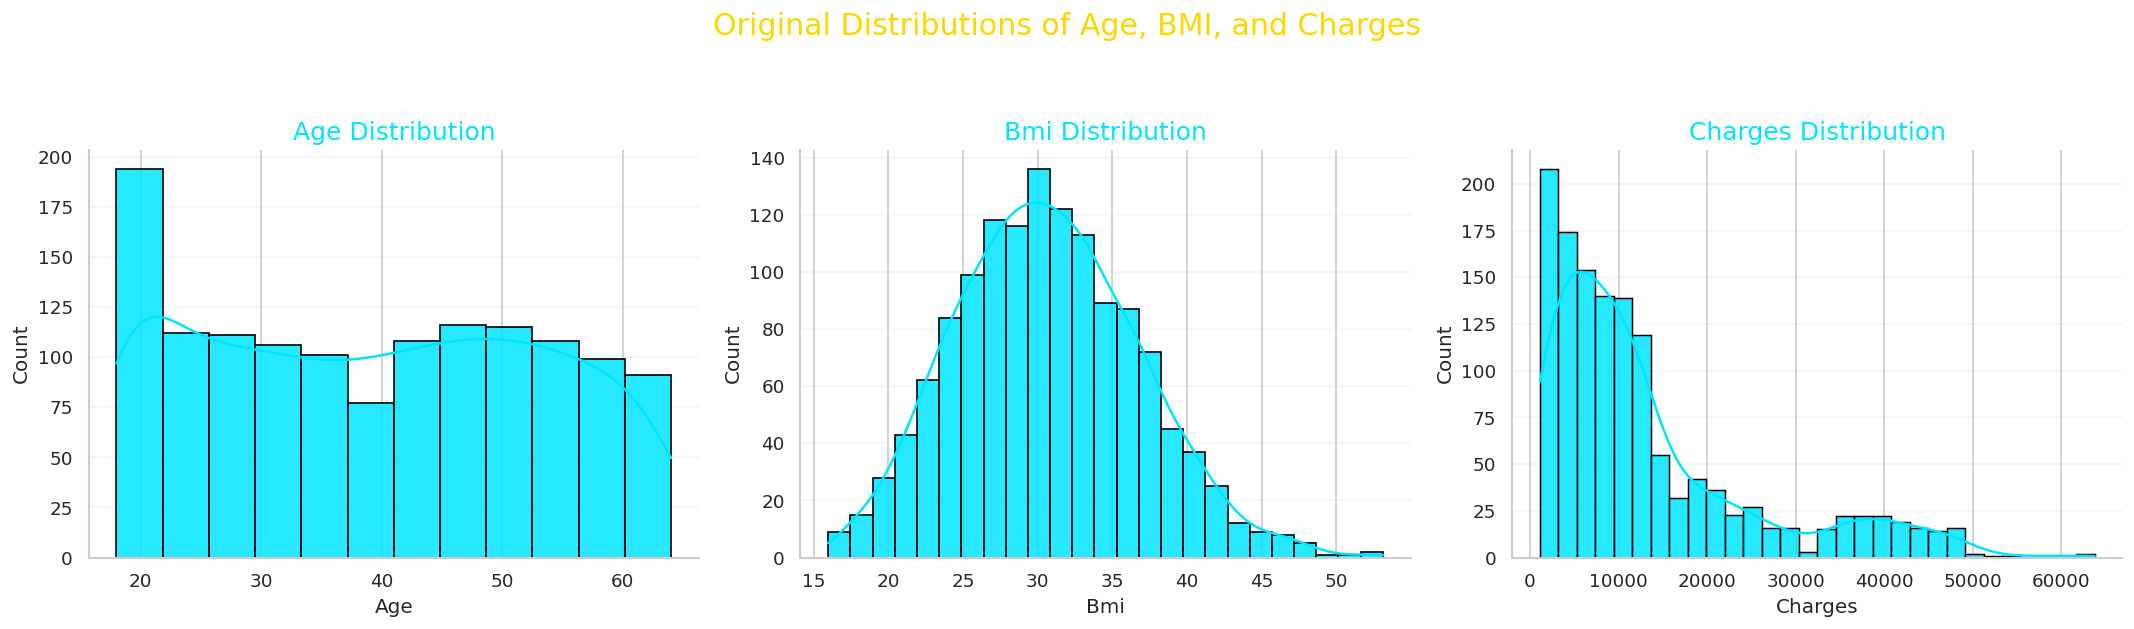

,Skewness
age,0.055673
bmi,0.284047
charges,1.515880


In [23]:
# ============================================================
# STEP 1: Visualize and Assess Skewness of Numerical Features
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["age", "bmi", "charges"]

plt.figure(figsize=(18, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, color="#00E5FF", edgecolor="black", alpha=0.85)
    plt.title(f"{col.capitalize()} Distribution", fontsize=15, color="#00E5FF")
    plt.xlabel(col.capitalize(), fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(axis='y', alpha=0.2)
plt.suptitle("Original Distributions of Age, BMI, and Charges", fontsize=18, color="#FFD700", y=1.05)
plt.tight_layout()
plt.show()

# Print skewness values in a styled DataFrame
skewness = df[num_cols].skew().to_frame(name="Skewness").style.background_gradient(cmap="coolwarm", axis=0)
display(skewness)

In [24]:
# ============================================================
# STEP 2: Apply Log and Power Transformations
# ============================================================

import numpy as np
from sklearn.preprocessing import PowerTransformer

# Log transformation (add small value to avoid log(0))
df["log_charges"] = np.log(df["charges"])
df["log_bmi"] = np.log(df["bmi"])

# Yeo-Johnson Power Transformation (works with zeros/negatives)
pt = PowerTransformer(method='yeo-johnson')
df[["yj_charges", "yj_bmi"]] = pt.fit_transform(df[["charges", "bmi"]])

print("✅ Log and Yeo-Johnson transformations applied to 'charges' and 'bmi'.")
display(df[["charges", "log_charges", "yj_charges", "bmi", "log_bmi", "yj_bmi"]].head())

✅ Log and Yeo-Johnson transformations applied to 'charges' and 'bmi'.


,charges,log_charges,yj_charges,bmi,log_bmi,yj_bmi
0,16884.92400,9.734176,0.681663,27.900,3.328627,-0.409919
1,1725.55230,7.453302,-1.748842,33.770,3.519573,0.548954
2,4449.46200,8.400538,-0.768811,33.000,3.496508,0.428603
3,21984.47061,9.998092,0.978834,22.705,3.122585,-1.353878
4,3866.85520,8.260197,-0.916592,28.880,3.363149,-0.242750


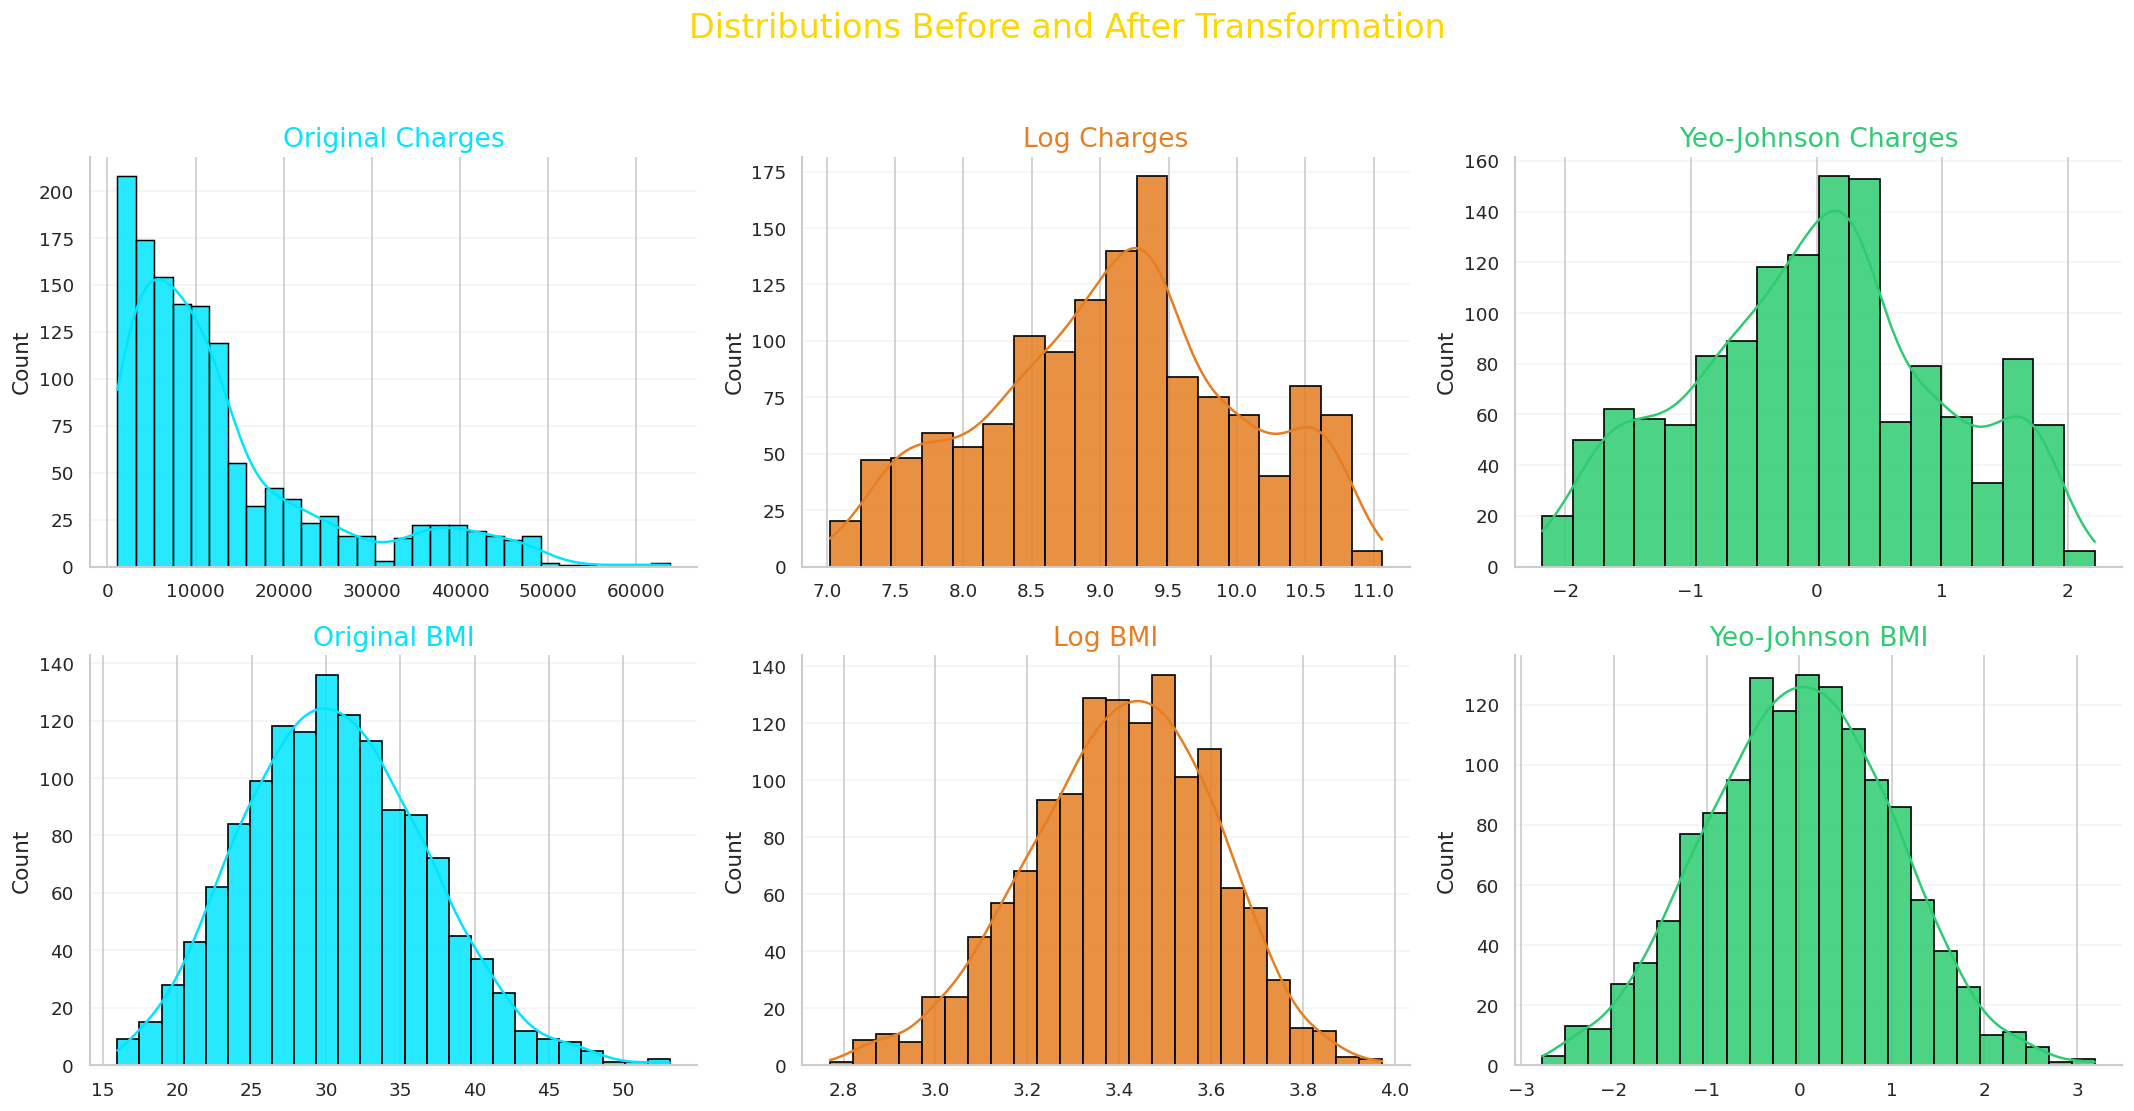

In [25]:
# ============================================================
# STEP 3: Visualize Transformed Distributions
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Original
sns.histplot(df["charges"], kde=True, color="#00E5FF", ax=axes[0,0], edgecolor="black", alpha=0.85)
axes[0,0].set_title("Original Charges", color="#00E5FF")
sns.histplot(df["bmi"], kde=True, color="#00E5FF", ax=axes[1,0], edgecolor="black", alpha=0.85)
axes[1,0].set_title("Original BMI", color="#00E5FF")

# Log-transformed
sns.histplot(df["log_charges"], kde=True, color="#e67e22", ax=axes[0,1], edgecolor="black", alpha=0.85)
axes[0,1].set_title("Log Charges", color="#e67e22")
sns.histplot(df["log_bmi"], kde=True, color="#e67e22", ax=axes[1,1], edgecolor="black", alpha=0.85)
axes[1,1].set_title("Log BMI", color="#e67e22")

# Yeo-Johnson transformed
sns.histplot(df["yj_charges"], kde=True, color="#2ecc71", ax=axes[0,2], edgecolor="black", alpha=0.85)
axes[0,2].set_title("Yeo-Johnson Charges", color="#2ecc71")
sns.histplot(df["yj_bmi"], kde=True, color="#2ecc71", ax=axes[1,2], edgecolor="black", alpha=0.85)
axes[1,2].set_title("Yeo-Johnson BMI", color="#2ecc71")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.grid(axis='y', alpha=0.2)

plt.suptitle("Distributions Before and After Transformation", fontsize=20, color="#FFD700", y=1.03)
plt.tight_layout()
plt.show()

In [26]:
# Encode 'sex' and 'smoker' if not already numeric
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

# One-hot encode 'region' if not already done
if "region" in df.columns:
    df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

In [27]:
# ============================================================
# STEP 4: Regression Modeling with Log-Transformed Target
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use log-transformed charges as target
y_log = df["log_charges"]
X = df.drop(["charges", "log_charges", "log_bmi", "yj_charges", "yj_bmi"], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict (in log scale)
y_pred_log = lr.predict(X_test_scaled)

# Convert predictions back to original scale
y_pred = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")

Mean Absolute Error (MAE):  $3,888.77
Root Mean Squared Error (RMSE):  $7,815.31


In [28]:
# ============================================================
# STEP 5: Interactive Actual vs Predicted Charges Plot (Log-Transformed Model)
# ============================================================

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "iframe"

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test_original,
    y=y_pred,
    mode='markers',
    marker=dict(size=9, color="#00E5FF", opacity=0.7, line=dict(width=1, color='white')),
    name="Predicted vs Actual",
    hovertemplate="Actual: $%{x:,.0f}<br>Predicted: $%{y:,.0f}"
))

# Perfect prediction line
min_val = min(y_test_original.min(), y_pred.min())
max_val = max(y_test_original.max(), y_pred.max())
fig.add_trace(go.Scatter(
    x=[min_val, max_val],
    y=[min_val, max_val],
    mode='lines',
    line=dict(color="#FFD700", width=3, dash="dash"),
    name="Perfect Prediction"
))

fig.update_layout(
    title="Actual vs Predicted Insurance Charges (Log-Transformed Model)",
    xaxis_title="Actual Charges ($)",
    yaxis_title="Predicted Charges ($)",
    font=dict(size=17, color="white"),
    title_font=dict(size=24, color="#00E5FF"),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    width=950,
    height=700,
    legend=dict(font=dict(size=15, color="white")),
    margin=dict(l=60, r=60, t=80, b=60)
)

fig.show()

In [29]:
# ============================================================
# Residuals vs Predicted Charges (Interactive)
# ============================================================

import plotly.express as px

residuals = y_test_original - y_pred

fig = px.scatter(
    x=y_pred, y=residuals,
    title="Residuals vs Predicted Charges (Log-Transformed Model)",
    labels={"x": "Predicted Charges ($)", "y": "Residuals ($)"},
    width=950, height=600,
    color=residuals,
    color_continuous_scale="RdBu"
)
fig.add_hline(y=0, line_dash="dash", line_color="#FFD700")
fig.update_traces(marker=dict(size=9, line=dict(width=1, color='white')))
fig.update_layout(
    title_font=dict(size=22, color="#00E5FF"),
    font=dict(size=16, color="white"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

In [30]:
# ============================================================
# Distribution of Prediction Errors (Residuals)
# ============================================================

import plotly.figure_factory as ff

fig = ff.create_distplot(
    [residuals],
    group_labels=["Prediction Errors (Residuals)"],
    colors=["#00E5FF"],
    show_rug=True,
    bin_size=1000
)
fig.update_layout(
    title="Distribution of Prediction Errors (Residuals)",
    xaxis_title="Residuals ($)",
    yaxis_title="Density",
    font=dict(size=16, color="white"),
    title_font=dict(size=22, color="#00E5FF"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    width=950, height=600,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

In [31]:
# ============================================================
# Feature Coefficients (Log-Transformed Model)
# ============================================================

import pandas as pd
import plotly.graph_objects as go

coef = lr.coef_
features = X.columns

coef_df = pd.DataFrame({"Feature": features, "Coefficient": coef}).sort_values("Coefficient", key=abs, ascending=False)

fig = go.Figure(go.Bar(
    x=coef_df["Coefficient"],
    y=coef_df["Feature"],
    orientation='h',
    marker_color=["#e74c3c" if c > 0 else "#3498db" for c in coef_df["Coefficient"]],
    text=[f"{c:.2f}" for c in coef_df["Coefficient"]],
    textposition="outside"
))
fig.update_layout(
    title="Linear Regression Feature Coefficients (Log-Transformed Model)",
    xaxis_title="Coefficient Value",
    yaxis_title="Feature",
    font=dict(size=16, color="white"),
    title_font=dict(size=22, color="#00E5FF"),
    plot_bgcolor="#222", paper_bgcolor="#222",
    width=950, height=600,
    margin=dict(l=60, r=60, t=80, b=60)
)
fig.show()

## 📝 Conclusion & Key Insights

- **Data Transformation:** To address skewness and variance in the `charges` and `bmi` features, I applied both log and Yeo-Johnson transformations. This made the distributions more symmetric and suitable for linear modeling.
- **Modeling:** Using the log-transformed `charges` as the target variable improved the regression model’s performance and produced more normally distributed residuals.
- **Key Predictors:** Smoking status, age, and BMI remain the most influential factors in predicting insurance charges.
- **Error Analysis:** The model’s MAE and RMSE indicate reasonable predictive accuracy, and residual plots show reduced skewness and more consistent errors after transformation.
- **Interpretation:** Feature coefficients from the log-transformed model provide clearer, more reliable insights into how each variable affects insurance costs.

### Recommendations:
- Always check for skewness and consider transformations for highly skewed features in regression tasks.
- Further improvements could be achieved by exploring non-linear models or additional feature engineering.

---

*This project demonstrates the value of thoughtful data transformation and interpretation in regression modeling.*